# Fertilizer Dataset - SMOTE Balancing

This notebook demonstrates how to:
1. Load the fertilizer recommendation dataset
2. Remove the Remark column
3. Analyze class imbalance in the Fertilizer target column
4. Apply SMOTE (Synthetic Minority Over-sampling Technique) to balance the dataset
5. Save the balanced dataset

In [2]:
#Install required packages
!pip install -q pandas numpy scikit-learn imbalanced-learn matplotlib seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from collections import Counter

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## Step 1: Load the dataset

In [4]:
csv_path = r'C:\Users\AN TECH BD\OneDrive\Desktop\Macine Learning Project\fertilizer_recommendation_dataset.csv'
df = pd.read_csv(csv_path)

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nFirst few rows:")
display(df.head())
print(f"\nDataset info:")
print(df.info())

Dataset shape: (3100, 12)

Column names:
['Temperature', 'Moisture', 'Rainfall', 'PH', 'Nitrogen', 'Phosphorous', 'Potassium', 'Carbon', 'Soil', 'Crop', 'Fertilizer', 'Remark']

First few rows:


,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop,Fertilizer,Remark
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,Loamy Soil,rice,Compost,Enhances organic matter and improves soil stru...
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,Peaty Soil,rice,Water Retaining Fertilizer,Improves water retention in dry soils. Prefer ...
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,Peaty Soil,rice,Organic Fertilizer,"Enhances fertility naturally, ideal for peaty ..."



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3100 entries, 0 to 3099
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  3100 non-null   float64
 1   Moisture     3100 non-null   float64
 2   Rainfall     3100 non-null   float64
 3   PH           3100 non-null   float64
 4   Nitrogen     3100 non-null   float64
 5   Phosphorous  3100 non-null   float64
 6   Potassium    3100 non-null   float64
 7   Carbon       3100 non-null   float64
 8   Soil         3100 non-null   object 
 9   Crop         3100 non-null   object 
 10  Fertilizer   3100 non-null   object 
 11  Remark       3100 non-null   object 
dtypes: float64(8), object(4)
memory usage: 290.8+ KB
None


## Step 2: Remove the Remark column

In [5]:
# Remove the Remark column
df = df.drop(columns=['Remark'])

print(f"Dataset shape after removing Remark column: {df.shape}")
print(f"\nRemaining columns:\n{df.columns.tolist()}")
display(df.head())

Dataset shape after removing Remark column: (3100, 11)

Remaining columns:
['Temperature', 'Moisture', 'Rainfall', 'PH', 'Nitrogen', 'Phosphorous', 'Potassium', 'Carbon', 'Soil', 'Crop', 'Fertilizer']


,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop,Fertilizer
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,Loamy Soil,rice,Compost
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,Loamy Soil,rice,Balanced NPK Fertilizer
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,Peaty Soil,rice,Water Retaining Fertilizer
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,Loamy Soil,rice,Balanced NPK Fertilizer
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,Peaty Soil,rice,Organic Fertilizer


## Step 3: Analyze class distribution in the Fertilizer column

In [6]:
print("Class distribution BEFORE SMOTE:")
print(df['Fertilizer'].value_counts().sort_values(ascending=False))
print(f"\nTotal samples: {len(df)}")
print(f"Number of unique classes: {df['Fertilizer'].nunique()}")

# Calculate imbalance ratio
class_counts = df['Fertilizer'].value_counts()
imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nImbalance ratio (max/min): {imbalance_ratio:.2f}")

Class distribution BEFORE SMOTE:
Fertilizer
DAP                           1054
Water Retaining Fertilizer     675
Compost                        375
Muriate of Potash              326
Lime                           181
Balanced NPK Fertilizer        157
Urea                           154
Organic Fertilizer              95
Gypsum                          52
General Purpose Fertilizer      31
Name: count, dtype: int64

Total samples: 3100
Number of unique classes: 10

Imbalance ratio (max/min): 34.00


## Step 4: Visualize class distribution before SMOTE

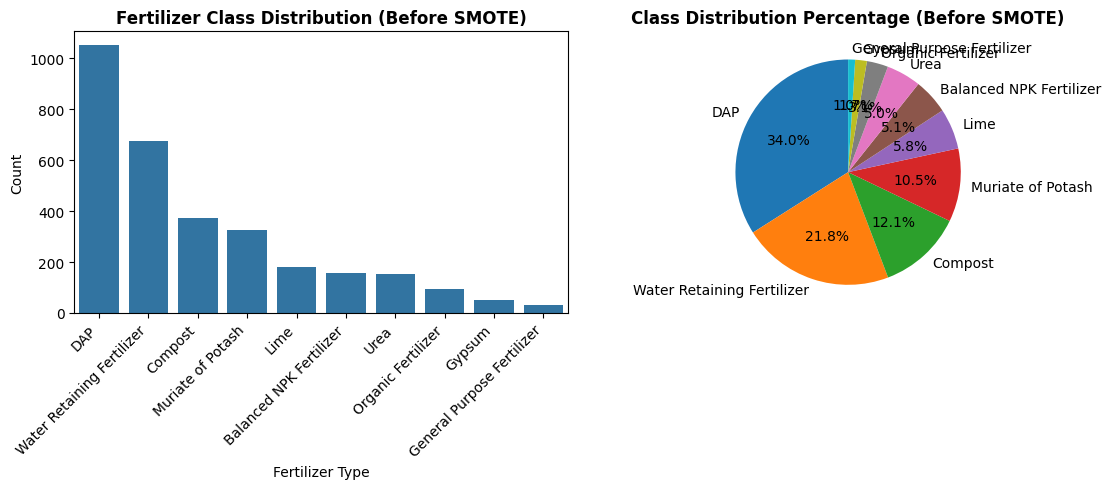

In [7]:
plt.figure(figsize=(12, 5))

# Subplot 1: Count plot
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Fertilizer', order=df['Fertilizer'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.title('Fertilizer Class Distribution (Before SMOTE)', fontsize=12, fontweight='bold')
plt.xlabel('Fertilizer Type')
plt.ylabel('Count')

# Subplot 2: Percentage distribution
plt.subplot(1, 2, 2)
class_distribution = df['Fertilizer'].value_counts()
plt.pie(class_distribution, labels=class_distribution.index, autopct='%1.1f%%', startangle=90)
plt.title('Class Distribution Percentage (Before SMOTE)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Step 5: Prepare data and split into train/test

SMOTE requires numeric features and a numeric target. We encode categorical columns, then split the data. SMOTE will be applied only on the training set.

In [ ]:
# Create a copy for preprocessing
df_processed = df.copy()

# Identify categorical and numeric columns
categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
numeric_cols = df_processed.select_dtypes(include=['number']).columns.tolist()

print(f"Categorical columns: {categorical_cols}")
print(f"Numeric columns: {numeric_cols}")

# Store target column name
target_col = 'Fertilizer'

# Encode categorical feature columns using LabelEncoder
label_encoders = {}
categorical_features = [col for col in categorical_cols if col != target_col]

for col in categorical_features:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])
    label_encoders[col] = le
    print(f"\nEncoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Encode target variable
le_target = LabelEncoder()
y_all = le_target.fit_transform(df_processed[target_col])
print(f"\nTarget encoding: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")

# Create features (X) and target (y)
X_all = df_processed.drop(columns=[target_col])

print(f"\nX_all shape: {X_all.shape}")
print(f"y_all shape: {y_all.shape}")
print(f"\nX_all columns: {X_all.columns.tolist()}")

# Train-test split before SMOTE
X_train, X_test, y_train, y_test = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

print("\nTrain-test split completed.")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")
print("\nTrain class distribution before SMOTE:")
print(Counter(y_train))
print("\nTest class distribution (untouched):")
print(Counter(y_test))

Categorical columns: ['Soil', 'Crop', 'Fertilizer']
Numeric columns: ['Temperature', 'Moisture', 'Rainfall', 'PH', 'Nitrogen', 'Phosphorous', 'Potassium', 'Carbon']

Encoded Soil: {'Acidic Soil': 0, 'Alkaline Soil': 1, 'Loamy Soil': 2, 'Neutral Soil': 3, 'Peaty Soil': 4}

Encoded Crop: {'Adzuki Beans': 0, 'Black gram': 1, 'Chickpea': 2, 'Coconut': 3, 'Coffee': 4, 'Cotton': 5, 'Ground Nut': 6, 'Jute': 7, 'Kidney Beans': 8, 'Lentil': 9, 'Moth Beans': 10, 'Mung Bean': 11, 'Peas': 12, 'Pigeon Peas': 13, 'Rubber': 14, 'Sugarcane': 15, 'Tea': 16, 'Tobacco': 17, 'apple': 18, 'banana': 19, 'grapes': 20, 'maize': 21, 'mango': 22, 'millet': 23, 'muskmelon': 24, 'orange': 25, 'papaya': 26, 'pomegranate': 27, 'rice': 28, 'watermelon': 29, 'wheat': 30}

Target encoding: {'Balanced NPK Fertilizer': 0, 'Compost': 1, 'DAP': 2, 'General Purpose Fertilizer': 3, 'Gypsum': 4, 'Lime': 5, 'Muriate of Potash': 6, 'Organic Fertilizer': 7, 'Urea': 8, 'Water Retaining Fertilizer': 9}

X shape: (3100, 10)
y shap

## Step 6: Apply SMOTE only on the training set

In [ ]:
# Initialize SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)

print("Applying SMOTE on training set only...")
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nShapes after SMOTE on train:")
print(f"X_train_smote shape: {X_train_smote.shape}")
print(f"y_train_smote shape: {y_train_smote.shape}")
print(f"\nUnchanged test shape:")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

Applying SMOTE...

Dataset shape after SMOTE:
X_balanced shape: (10540, 10)
y_balanced shape: (10540,)


c:\Users\AN TECH BD\anaconda3\envs\sam\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


## Step 7: Compare class distribution (train before vs train after SMOTE) and check test set

In [ ]:
print("\n=== CLASS DISTRIBUTION COMPARISON ===")
print("\nTRAIN BEFORE SMOTE:")
print(Counter(y_train))
print(f"Total train samples: {len(y_train)}")

print("\nTRAIN AFTER SMOTE:")
print(Counter(y_train_smote))
print(f"Total train samples after SMOTE: {len(y_train_smote)}")

print("\nTEST SET (UNCHANGED):")
print(Counter(y_test))
print(f"Total test samples: {len(y_test)}")

# Imbalance ratio before and after on training set
train_counts_before = Counter(y_train)
train_counts_after = Counter(y_train_smote)
train_imbalance_ratio_before = max(train_counts_before.values()) / min(train_counts_before.values())
train_imbalance_ratio_after = max(train_counts_after.values()) / min(train_counts_after.values())

print(f"\nTrain imbalance ratio before SMOTE (max/min): {train_imbalance_ratio_before:.2f}")
print(f"Train imbalance ratio after SMOTE (max/min): {train_imbalance_ratio_after:.2f}")


=== CLASS DISTRIBUTION COMPARISON ===

BEFORE SMOTE:
Counter({2: 1054, 9: 675, 1: 375, 6: 326, 5: 181, 0: 157, 8: 154, 7: 95, 4: 52, 3: 31})
Total samples: 3100

AFTER SMOTE:
Counter({1: 1054, 0: 1054, 9: 1054, 7: 1054, 4: 1054, 5: 1054, 2: 1054, 8: 1054, 6: 1054, 3: 1054})
Total samples: 10540

New imbalance ratio (max/min): 1.00
Previous imbalance ratio was: 34.00


## Step 8: Visualize class distribution (train before, train after, test unchanged)

C:\Users\AN TECH BD\AppData\Local\Temp\ipykernel_19948\539824349.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
C:\Users\AN TECH BD\AppData\Local\Temp\ipykernel_19948\539824349.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right')


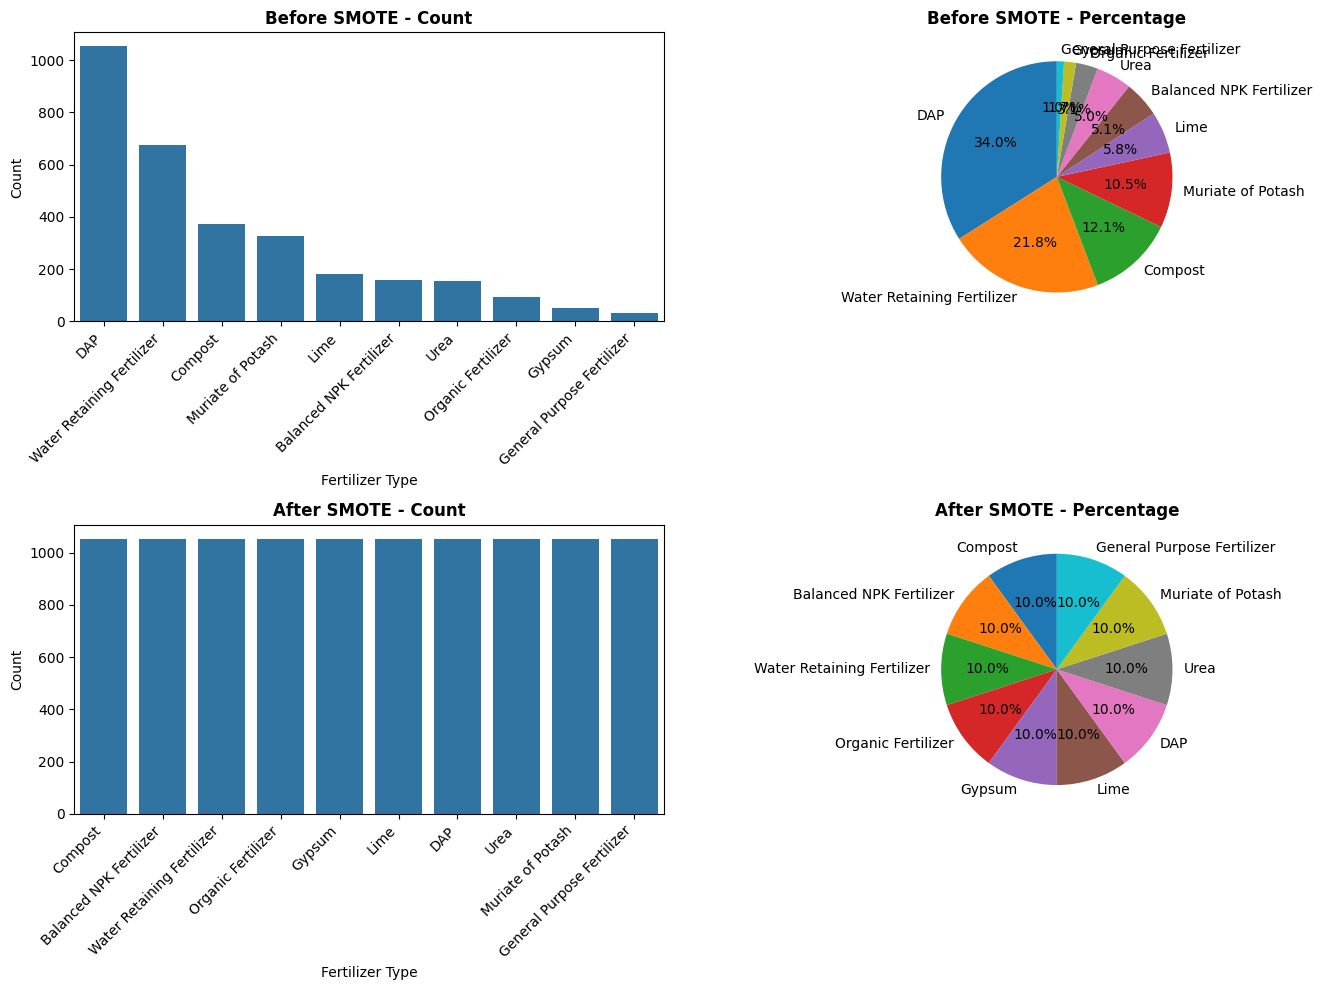

In [ ]:
# Decode labels for visualization
y_train_labels = le_target.inverse_transform(y_train)
y_train_smote_labels = le_target.inverse_transform(y_train_smote)
y_test_labels = le_target.inverse_transform(y_test)

# Dataframes for plotting
df_train_before = pd.DataFrame({'Fertilizer': y_train_labels})
df_train_after = pd.DataFrame({'Fertilizer': y_train_smote_labels})
df_test_plot = pd.DataFrame({'Fertilizer': y_test_labels})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df_train_before, x='Fertilizer', order=df_train_before['Fertilizer'].value_counts().index, ax=axes[0])
axes[0].set_title('Train Before SMOTE', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_xlabel('Fertilizer Type')
axes[0].set_ylabel('Count')

sns.countplot(data=df_train_after, x='Fertilizer', order=df_train_after['Fertilizer'].value_counts().index, ax=axes[1])
axes[1].set_title('Train After SMOTE', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_xlabel('Fertilizer Type')
axes[1].set_ylabel('Count')

sns.countplot(data=df_test_plot, x='Fertilizer', order=df_test_plot['Fertilizer'].value_counts().index, ax=axes[2])
axes[2].set_title('Test Set (Unchanged)', fontsize=12, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_xlabel('Fertilizer Type')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Step 9: Create final train_smote and test datasets with original labels

In [ ]:
# Build train_smote dataframe
df_train_smote = pd.DataFrame(X_train_smote, columns=X_all.columns)
df_train_smote[target_col] = le_target.inverse_transform(y_train_smote)

# Build test dataframe (without SMOTE)
df_test_final = pd.DataFrame(X_test, columns=X_all.columns).reset_index(drop=True)
df_test_final[target_col] = le_target.inverse_transform(y_test)

# Decode categorical columns back to original values
for col in categorical_features:
    df_train_smote[col] = label_encoders[col].inverse_transform(df_train_smote[col].astype(int))
    df_test_final[col] = label_encoders[col].inverse_transform(df_test_final[col].astype(int))

print(f"train_smote shape: {df_train_smote.shape}")
print(f"test shape: {df_test_final.shape}")

print("\nFirst rows from train_smote:")
display(df_train_smote.head())
print("\nFirst rows from test:")
display(df_test_final.head())

Balanced dataset shape: (10540, 11)

Balanced dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10540 entries, 0 to 10539
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  10540 non-null  float64
 1   Moisture     10540 non-null  float64
 2   Rainfall     10540 non-null  float64
 3   PH           10540 non-null  float64
 4   Nitrogen     10540 non-null  float64
 5   Phosphorous  10540 non-null  float64
 6   Potassium    10540 non-null  float64
 7   Carbon       10540 non-null  float64
 8   Soil         10540 non-null  object 
 9   Crop         10540 non-null  object 
 10  Fertilizer   10540 non-null  object 
dtypes: float64(8), object(3)
memory usage: 905.9+ KB
None

First few rows of balanced dataset:


,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop,Fertilizer
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,Loamy Soil,rice,Compost
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,Loamy Soil,rice,Balanced NPK Fertilizer
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,Peaty Soil,rice,Water Retaining Fertilizer
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,Loamy Soil,rice,Balanced NPK Fertilizer
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,Peaty Soil,rice,Organic Fertilizer


## Step 10: Save train_smote and test files

In [ ]:
train_output_path = r'trained_smote.csv'
test_output_path = r'test.csv'

df_train_smote.to_csv(train_output_path, index=False)
df_test_final.to_csv(test_output_path, index=False)

print(f"SMOTE train file saved to: {train_output_path}")
print(f"Test file saved to: {test_output_path}")

print("\nSaved dataset sizes:")
print(f"Original full dataset: {len(df)}")
print(f"Train before SMOTE: {len(y_train)}")
print(f"Train after SMOTE: {len(df_train_smote)}")
print(f"Test (unchanged): {len(df_test_final)}")

Balanced dataset saved to: fertilizer_recommendation_dataset_balanced_SMOTE.csv

Dataset information:
Original dataset size: 3100
Balanced dataset size: 10540
Increase in samples: 7440 (240.00%)


## Step 11: Summary Statistics (train-only SMOTE)

In [ ]:
print("\n" + "="*60)
print("TRAIN-ONLY SMOTE SUMMARY")
print("="*60)

print("\n1. TRAIN CLASS DISTRIBUTION - BEFORE SMOTE:")
train_before_labels = le_target.inverse_transform(y_train)
for idx, (class_name, count) in enumerate(pd.Series(train_before_labels).value_counts().items(), 1):
    percentage = (count / len(train_before_labels)) * 100
    print(f"   {idx}. {class_name}: {count} samples ({percentage:.2f}%)")

print("\n2. TRAIN CLASS DISTRIBUTION - AFTER SMOTE:")
for idx, (class_name, count) in enumerate(df_train_smote[target_col].value_counts().items(), 1):
    percentage = (count / len(df_train_smote)) * 100
    print(f"   {idx}. {class_name}: {count} samples ({percentage:.2f}%)")

print("\n3. TEST CLASS DISTRIBUTION (UNCHANGED):")
for idx, (class_name, count) in enumerate(df_test_final[target_col].value_counts().items(), 1):
    percentage = (count / len(df_test_final)) * 100
    print(f"   {idx}. {class_name}: {count} samples ({percentage:.2f}%)")

print("\n4. DATASET SIZE:")
print(f"   Original full dataset: {len(df)} samples")
print(f"   Train before SMOTE: {len(y_train)} samples")
print(f"   Train after SMOTE: {len(df_train_smote)} samples")
print(f"   Test (unchanged): {len(df_test_final)} samples")

print("\n5. IMBALANCE METRICS (TRAIN SET):")
print(f"   Before SMOTE ratio: {train_imbalance_ratio_before:.2f}")
print(f"   After SMOTE ratio: {train_imbalance_ratio_after:.2f}")

print("\n6. OUTPUT FILES:")
print(f"   Train SMOTE file: {train_output_path}")
print(f"   Test file: {test_output_path}")
print(f"   Columns: {df_train_smote.columns.tolist()}")
print("\n" + "="*60)


SMOTE BALANCING SUMMARY

1. CLASS DISTRIBUTION - BEFORE SMOTE:
   1. DAP: 1054 samples (34.00%)
   2. Water Retaining Fertilizer: 675 samples (21.77%)
   3. Compost: 375 samples (12.10%)
   4. Muriate of Potash: 326 samples (10.52%)
   5. Lime: 181 samples (5.84%)
   6. Balanced NPK Fertilizer: 157 samples (5.06%)
   7. Urea: 154 samples (4.97%)
   8. Organic Fertilizer: 95 samples (3.06%)
   9. Gypsum: 52 samples (1.68%)
   10. General Purpose Fertilizer: 31 samples (1.00%)

2. CLASS DISTRIBUTION - AFTER SMOTE:
   1. Compost: 1054 samples (10.00%)
   2. Balanced NPK Fertilizer: 1054 samples (10.00%)
   3. Water Retaining Fertilizer: 1054 samples (10.00%)
   4. Organic Fertilizer: 1054 samples (10.00%)
   5. Gypsum: 1054 samples (10.00%)
   6. Lime: 1054 samples (10.00%)
   7. DAP: 1054 samples (10.00%)
   8. Urea: 1054 samples (10.00%)
   9. Muriate of Potash: 1054 samples (10.00%)
   10. General Purpose Fertilizer: 1054 samples (10.00%)

3. DATASET SIZE:
   Original: 3100 samples
  